In [80]:
## imports from activity 6: apis_blank
import pandas as pd
import numpy as np
import re
import requests
import yaml
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

## set font parameters early
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [97]:
## define key parameters
article = "Bosnia_and_Herzegovina"
start_date = 20260601
end_date = 20260730

## pull the test query from ssrn journal
test_query = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/'
             f'all-access/all-agents/{article}/daily/{start_date}/{end_date}')

## mandatory header for MediaWiki, no API key needed
headers = {
    'User-Agent': 'EskildsenLogan research project (logan.j.eskildsen.28@dartmouth.edu)'
}

## pull and format requests
test_pull = requests.get(test_query, headers=headers)
##test_pull

test_pull_convert = test_pull.json()
##test_pull_convert

## get baseline data
start_date_2 = 20260101
end_date_2 = 20260110

test_query_2 = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/'
             f'all-access/all-agents/{article}/daily/{start_date_2}/{end_date_2}')

test_pull_2 = requests.get(test_query_2, headers=headers)
test_pull_convert_2 = test_pull_2.json()
##test_pull_convert_2

## find necessary key
print(test_pull_convert.keys())


article_2 = "Netherlands"
start_2_date = 20221110
end_2_date = 20221228
test_2_query = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/'
             f'all-access/all-agents/{article_2}/daily/{start_2_date}/{end_2_date}')
test_2_pull_convert = requests.get(test_2_query, headers=headers).json()

start_2_date_2 = 20220101
end_2_date_2 = 20220110

test_2_query_2 = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/'
             f'all-access/all-agents/{article_2}/daily/{start_2_date_2}/{end_2_date_2}')
test_2_pull_convert_2 = requests.get(test_2_query_2, headers=headers).json()

dict_keys(['items'])


In [98]:
## Create dataframes
test_d = pd.DataFrame(test_pull_convert['items'])

## Calculate mean views as baseline
test_d_2 = pd.DataFrame(test_pull_convert_2['items'])
baseline = round(test_d_2['views'].mean())

## Create an effective date column
test_d['date'] = pd.to_datetime(test_d.timestamp.str[:8], format='%Y%m%d')

## Create the marginal views column
test_d['views_ratio'] = test_d['views'] / baseline
test_d[['article', 'date', 'views', 'views_ratio']]


## Repeat for Netherlands
test_2_d = pd.DataFrame(test_2_pull_convert['items'])

test_2_d_2 = pd.DataFrame(test_2_pull_convert_2['items'])
baseline = round(test_2_d_2['views'].mean())

test_2_d['date'] = pd.to_datetime(test_2_d.timestamp.str[:8], format='%Y%m%d')

test_2_d['views_ratio'] = test_2_d['views'] / baseline
test_2_d[['article', 'date', 'views', 'views_ratio']]



,article,date,views,views_ratio
0,Bosnia_and_Herzegovina,2026-06-01,6996,1.434488
1,Bosnia_and_Herzegovina,2026-06-02,7128,1.461554
2,Bosnia_and_Herzegovina,2026-06-03,7208,1.477958
3,Bosnia_and_Herzegovina,2026-06-04,7305,1.497847
4,Bosnia_and_Herzegovina,2026-06-05,8096,1.660037
5,Bosnia_and_Herzegovina,2026-06-06,8316,1.705147
6,Bosnia_and_Herzegovina,2026-06-07,8629,1.769325
7,Bosnia_and_Herzegovina,2026-06-08,9724,1.993849
8,Bosnia_and_Herzegovina,2026-06-09,9861,2.021940
9,Bosnia_and_Herzegovina,2026-06-10,11485,2.354931


,article,date,views,views_ratio
0,Netherlands,2022-11-10,18092,1.351359
1,Netherlands,2022-11-11,18362,1.371527
2,Netherlands,2022-11-12,17543,1.310353
3,Netherlands,2022-11-13,19045,1.422543
4,Netherlands,2022-11-14,19326,1.443532
5,Netherlands,2022-11-15,19347,1.445100
6,Netherlands,2022-11-16,19765,1.476322
7,Netherlands,2022-11-17,19578,1.462354
8,Netherlands,2022-11-18,19111,1.427472
9,Netherlands,2022-11-19,18509,1.382507


Estimated half-life: 1.63 days


Text(0.5, 1.0, 'Wikipedia Daily Views: Bosnia and Herzegovina (2026)')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(array([20603., 20606., 20609., 20612., 20615., 20618., 20621., 20624.,
        20627., 20630., 20633., 20636., 20639., 20642., 20645., 20648.,
        20651., 20654., 20657., 20660., 20663., 20666.]),
 [Text(20603.0, 0, 'May 30'),
  Text(20606.0, 0, 'Jun 02'),
  Text(20609.0, 0, 'Jun 05'),
  Text(20612.0, 0, 'Jun 08'),
  Text(20615.0, 0, 'Jun 11'),
  Text(20618.0, 0, 'Jun 14'),
  Text(20621.0, 0, 'Jun 17'),
  Text(20624.0, 0, 'Jun 20'),
  Text(20627.0, 0, 'Jun 23'),
  Text(20630.0, 0, 'Jun 26'),
  Text(20633.0, 0, 'Jun 29'),
  Text(20636.0, 0, 'Jul 02'),
  Text(20639.0, 0, 'Jul 05'),
  Text(20642.0, 0, 'Jul 08'),
  Text(20645.0, 0, 'Jul 11'),
  Text(20648.0, 0, 'Jul 14'),
  Text(20651.0, 0, 'Jul 17'),
  Text(20654.0, 0, 'Jul 20'),
  Text(20657.0, 0, 'Jul 23'),
  Text(20660.0, 0, 'Jul 26'),
  Text(20663.0, 0, 'Jul 29'),
  Text(20666.0, 0, 'Aug 01')])

(1.0, 69.04896452737339)

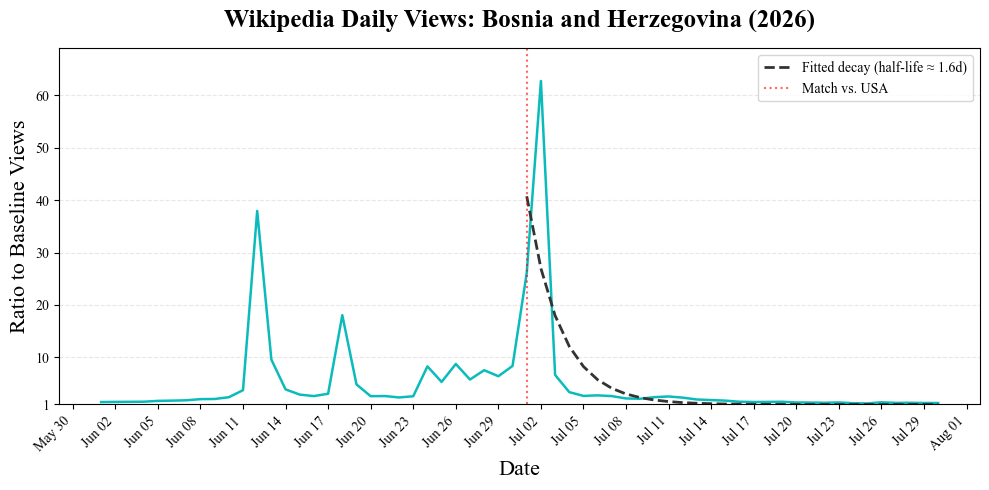

<Figure size 640x480 with 0 Axes>

In [104]:
## Define exponential decay function (ratio decays toward 1, not 0)
def decay_func(t, A, lam, baseline):
    return A * np.exp(-lam * t) + baseline

## Isolate data from the match date onward
match_date = pd.Timestamp('2026-07-01')
post_match = test_d[test_d['date'] >= match_date].copy()
post_match['days_since_match'] = (post_match['date'] - match_date).dt.days

## Fit the curve
p0 = [post_match['views_ratio'].iloc[0] - 1, 
      0.2, 
      1]  # baseline ratio should decay toward 1, not 0

params, _ = curve_fit(decay_func, post_match['days_since_match'], post_match['views_ratio'], 
                       p0=p0, maxfev=10000)
A_fit, lam_fit, baseline_fit = params

## Evaluate the fitted curve at the actual observed days (no smoothing)
fitted_curve = decay_func(post_match['days_since_match'], A_fit, lam_fit, baseline_fit)

## Half-life
half_life = np.log(2) / lam_fit
print(f"Estimated half-life: {half_life:.2f} days")

## Visualize the data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_d['date'], test_d['views_ratio'], color='#0BBBBB', linewidth=1.8)

## Overlay the fitted decay curve
ax.plot(post_match['date'], fitted_curve, color='#333333', linewidth=2, linestyle='--', 
        label=f'Fitted decay (half-life ≈ {half_life:.1f}d)')

## Formatting
ax.set_title(f"Wikipedia Daily Views: {test_d['article'].iloc[0].replace('_', ' ')} ({test_d['date'].iloc[0].year})", 
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("Ratio to Baseline Views", fontsize=16)

## Clean up date ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45, ha='right')

## y-axis force bottom tick at 1
plt.ylim(1, max(test_d['views_ratio'])*1.1)
current_ticks = ax.get_yticks()
new_ticks = np.unique(np.append(current_ticks, 1))
new_ticks = new_ticks[(new_ticks >= 1) & (new_ticks <= 65)]  # keep within visible range
ax.set_yticks(new_ticks)

## gridlines
ax.grid(axis='y', alpha=0.3, linestyle='--')

## v-line for match against US
ax.axvline(match_date, color='red', linestyle=':', alpha=0.6, label='Match vs. USA')
ax.legend()
plt.tight_layout()
plt.show()

plt.savefig('example_visual.png', 
    dpi=300, 
    bbox_inches='tight', 
    transparent=True,
    facecolor='w')

Estimated half-life: 3.25 days


Text(0.5, 1.0, 'Wikipedia Daily Views: Netherlands (2022)')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Ratio to Baseline Views')

(array([19306., 19309., 19312., 19315., 19318., 19321., 19324., 19327.,
        19330., 19333., 19336., 19339., 19342., 19345., 19348., 19351.,
        19354.]),
 [Text(19306.0, 0, 'Nov 10'),
  Text(19309.0, 0, 'Nov 13'),
  Text(19312.0, 0, 'Nov 16'),
  Text(19315.0, 0, 'Nov 19'),
  Text(19318.0, 0, 'Nov 22'),
  Text(19321.0, 0, 'Nov 25'),
  Text(19324.0, 0, 'Nov 28'),
  Text(19327.0, 0, 'Dec 01'),
  Text(19330.0, 0, 'Dec 04'),
  Text(19333.0, 0, 'Dec 07'),
  Text(19336.0, 0, 'Dec 10'),
  Text(19339.0, 0, 'Dec 13'),
  Text(19342.0, 0, 'Dec 16'),
  Text(19345.0, 0, 'Dec 19'),
  Text(19348.0, 0, 'Dec 22'),
  Text(19351.0, 0, 'Dec 25'),
  Text(19354.0, 0, 'Dec 28')])

(1.0, 6.902360322677025)

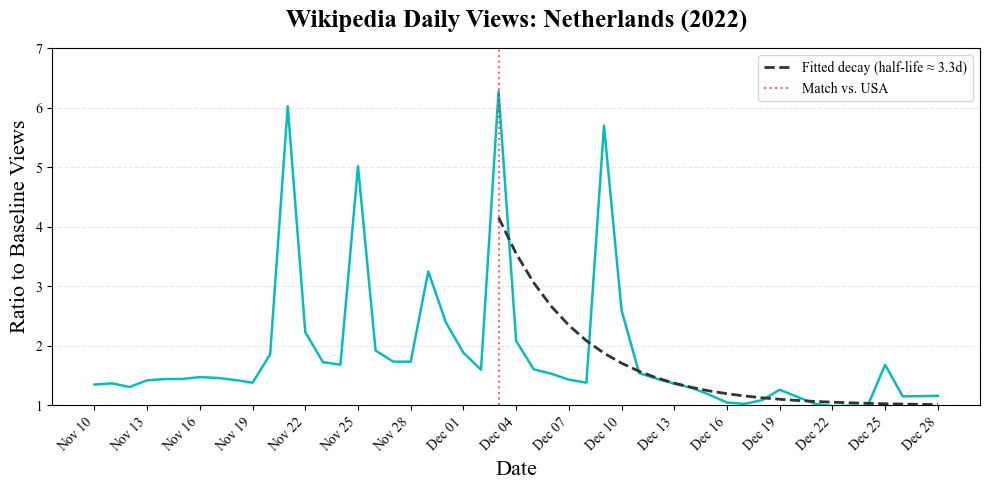

In [105]:
import numpy as np
from scipy.optimize import curve_fit

## Define exponential decay function, baseline fixed at 1 (ratio approaches 1, not estimated)
def decay_func_fixed(t, A, lam):
    return A * np.exp(-lam * t) + 1

## Isolate data from the match date onward
match_date = pd.Timestamp('2022-12-03')
post_match = test_2_d[test_2_d['date'] >= match_date].copy()
post_match['days_since_match'] = (post_match['date'] - match_date).dt.days

## Fit the curve
p0 = [post_match['views_ratio'].iloc[0] - 1, 0.2]

params, _ = curve_fit(decay_func_fixed, post_match['days_since_match'], post_match['views_ratio'], 
                       p0=p0, maxfev=10000, method='trf')
A_fit, lam_fit = params

## Evaluate the fitted curve at the actual observed days (no smoothing)
fitted_curve = decay_func_fixed(post_match['days_since_match'], A_fit, lam_fit)

## Half-life
half_life = np.log(2) / lam_fit
print(f"Estimated half-life: {half_life:.2f} days")

## Visualize the data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_2_d['date'], test_2_d['views_ratio'], color='#0BBBBB', linewidth=1.8)

## Overlay the fitted decay curve
ax.plot(post_match['date'], fitted_curve, color='#333333', linewidth=2, linestyle='--', 
        label=f'Fitted decay (half-life ≈ {half_life:.1f}d)')

## Formatting
ax.set_title(f"Wikipedia Daily Views: {test_2_d['article'].iloc[0].replace('_', ' ')} ({test_2_d['date'].iloc[0].year})", 
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("Ratio to Baseline Views", fontsize=16)

## Clean up date ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45, ha='right')

## y-axis: force bottom tick at 1
plt.ylim(1, max(test_2_d['views_ratio'])*1.1)
current_ticks = ax.get_yticks()
new_ticks = np.unique(np.append(current_ticks, 1))
new_ticks = new_ticks[(new_ticks >= 1) & (new_ticks <= 65)]
ax.set_yticks(new_ticks)

## gridlines
ax.grid(axis='y', alpha=0.3, linestyle='--')

## v-line for match against US
ax.axvline(match_date, color='red', linestyle=':', alpha=0.6, label='Match vs. USA')
ax.legend()
plt.tight_layout()
plt.show()